# 06c — CLEAR VAE Latent Counterfactual Optimization

## VAE extension — vera ricerca controfattuale nello spazio latente

Questo notebook implementa la fase che mancava per avere una vera estensione VAE-based di CLEAR.

La Pipeline 2 consolidata resta invariata.

```text
Pipeline 2 consolidata
04c → 04d → 04e → 05c → 05d → 05e

VAE extension
06a VAE training
→ 06b latent-space analysis
→ 06c latent counterfactual optimization   ← questo notebook
→ 06d VAE-CLEAR vs Direct CLEAR
```

Il `06b` deve avere mostrato uno spazio latente sufficientemente informativo (`READY_FOR_06C`).

## Principio

Partiamo dal seed:

```text
F0010 = IGERCQYRDLK
```

e dal suo codice latente:

\[
z_{seed} = Encoder(F0010)
\]

Poi ottimizziamo direttamente un vettore latente:

\[
z_{cf}
\]

Il decoder VAE produce distribuzioni categoriali sugli amminoacidi:

\[
z_{cf} \rightarrow p_\theta(x|z_{cf})
\]

e l'oracolo GNN del 04d valuta differenziabilmente queste distribuzioni.

La funzione obiettivo combina:

\[
L =
-L_{oracle}
+ \lambda_z ||z-z_{seed}||_2^2
+ \lambda_{mut} L_{mutazioni}
+ \lambda_H H(p)
+ \lambda_{invalid} L_{vincoli}
\]

con:

- miglioramento dell'oracolo;
- località nello spazio latente;
- massimo 1–2 mutazioni;
- posizioni protette;
- sostituzioni ammesse dal 04c;
- decoding finale hard e validazione esplicita.

### Importante

Questo notebook non dimostra binding o affinità.

Genera **controfattuali VAE-CLEAR locali** che, se promettenti, potranno essere confrontati con Direct CLEAR nel 06d e solo successivamente sottoposti a FoldX/Rosetta.


## 1. Dipendenze

In [1]:
from pathlib import Path
from collections import Counter
import json
import math
import random
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 220)
pd.set_option("display.max_colwidth", 180)

RANDOM_SEED = 20260807

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = (
    torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("cpu")
)

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

PyTorch: 2.2.1
Device: mps


## 2. Percorsi e configurazione

In [2]:
OUTPUT_DIR = Path("outputs")

DATASET_04C_DIR = (
    OUTPUT_DIR
    / "clear_local_peptide_dataset_04c"
)

ORACLE_04D_DIR = (
    OUTPUT_DIR
    / "clear_peptide_oracle_04d"
)

DIRECT_CLEAR_04E_DIR = (
    OUTPUT_DIR
    / "clear_peptide_counterfactuals_04e"
)

VAE_06A_DIR = (
    OUTPUT_DIR
    / "clear_peptide_vae_06a"
)

VAE_06B_DIR = (
    OUTPUT_DIR
    / "clear_peptide_vae_06b"
)

RESULT_DIR = (
    OUTPUT_DIR
    / "clear_peptide_vae_counterfactuals_06c"
)

REPORT_DIR = RESULT_DIR / "reports"
VALIDATION_DIR = RESULT_DIR / "validation_panel"

for directory in [
    RESULT_DIR,
    REPORT_DIR,
    VALIDATION_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

VAE_MODEL_PATH = (
    VAE_06A_DIR
    / "models"
    / "clear_peptide_vae.pt"
)

VAE_LATENT_CSV = (
    VAE_06A_DIR
    / "vae_latent_embeddings.csv"
)

READINESS_CSV = (
    VAE_06B_DIR
    / "06c_readiness_checks.csv"
)

LATENT_DIRECTION_CSV = (
    VAE_06B_DIR
    / "latent_target_direction_proxy.csv"
)

ORACLE_MODEL_PATH = (
    ORACLE_04D_DIR
    / "models"
    / "clear_peptide_oracle_gnn.pt"
)

TARGET_SCALER_PATH = (
    ORACLE_04D_DIR
    / "models"
    / "target_scaler.joblib"
)

ORACLE_CONFIG_PATH = (
    ORACLE_04D_DIR
    / "models"
    / "oracle_config.json"
)

POSITION_CONSTRAINTS_CSV = (
    DATASET_04C_DIR
    / "library"
    / "clear_position_constraints.csv"
)

LABELED_DATASET_CSV = (
    DATASET_04C_DIR
    / "clear_local_peptide_variant_dataset_labeled.csv"
)

# Counterfactual constraints
MAX_MUTATIONS = 2
MIN_ORACLE_IMPROVEMENT = 0.005

# Latent optimization
N_RESTARTS = 80
OPTIMIZATION_STEPS = 350
LEARNING_RATE = 0.035

TEMPERATURE_START = 1.20
TEMPERATURE_END = 0.20

# Objective weights
LAMBDA_LATENT = 0.020
LAMBDA_ENTROPY = 0.010
LAMBDA_EXCESS_MUTATIONS = 1.50
LAMBDA_INVALID_MASS = 8.0

# Keep the search local in the VAE manifold.
MAX_LATENT_RADIUS = 2.25
LAMBDA_RADIUS = 1.00

TOP_N_EXPORT = 30
TOP_N_VALIDATION = 10

print("Output:", RESULT_DIR.resolve())

Output: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_counterfactuals_06c


## 3. Controllo degli input

In [3]:
required_paths = [
    VAE_MODEL_PATH,
    VAE_LATENT_CSV,
    ORACLE_MODEL_PATH,
    TARGET_SCALER_PATH,
    ORACLE_CONFIG_PATH,
    POSITION_CONSTRAINTS_CSV,
    LABELED_DATASET_CSV,
]

missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "File mancanti:\n"
        + "\n".join(
            str(path)
            for path in missing_paths
        )
    )

print("Tutti gli input essenziali sono disponibili.")

if READINESS_CSV.exists():
    readiness = pd.read_csv(
        READINESS_CSV
    )
    display(readiness)

    if not bool(
        readiness["passed"].all()
    ):
        print(
            "ATTENZIONE: non tutti i quality checks "
            "del 06b risultano superati."
        )
else:
    print(
        "ATTENZIONE: 06c_readiness_checks.csv "
        "non trovato; continuo usando gli artefatti disponibili."
    )

Tutti gli input essenziali sono disponibili.


,check,passed,value
0,F0010 present in latent space,True,1.000000
1,mean latent std > 0.01,True,0.877891
2,"Spearman(Hamming, latent distance) > 0.20",True,0.595039
3,local target smoothness Spearman > 0.30,True,0.623928
4,latent-only Ridge CV R2 > 0.10,True,0.140126


## 4. Ricostruzione del VAE 06a

In [4]:
class PeptideVAE(nn.Module):
    def __init__(
        self,
        seq_len,
        n_aa,
        embed_dim,
        hidden_dim,
        latent_dim,
    ):
        super().__init__()

        self.seq_len = seq_len
        self.n_aa = n_aa
        self.embed_dim = embed_dim
        self.latent_dim = latent_dim

        self.embedding = nn.Embedding(
            n_aa,
            embed_dim,
        )

        self.encoder = nn.Sequential(
            nn.Linear(
                seq_len * embed_dim,
                hidden_dim,
            ),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(
                hidden_dim,
                hidden_dim // 2,
            ),
            nn.ReLU(),
        )

        self.mu_head = nn.Linear(
            hidden_dim // 2,
            latent_dim,
        )

        self.logvar_head = nn.Linear(
            hidden_dim // 2,
            latent_dim,
        )

        self.decoder = nn.Sequential(
            nn.Linear(
                latent_dim,
                hidden_dim // 2,
            ),
            nn.ReLU(),
            nn.Linear(
                hidden_dim // 2,
                hidden_dim,
            ),
            nn.ReLU(),
            nn.Linear(
                hidden_dim,
                seq_len * n_aa,
            ),
        )

    def encode(self, x):
        embedded = self.embedding(x)
        hidden = self.encoder(
            embedded.reshape(
                x.size(0),
                -1,
            )
        )

        return (
            self.mu_head(hidden),
            self.logvar_head(hidden),
        )

    def reparameterize(
        self,
        mu,
        logvar,
    ):
        return (
            mu
            + torch.randn_like(mu)
            * torch.exp(
                0.5 * logvar
            )
        )

    def decode(self, z):
        logits = self.decoder(z)

        return logits.reshape(
            z.size(0),
            self.seq_len,
            self.n_aa,
        )

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(
            mu,
            logvar,
        )

        return (
            self.decode(z),
            mu,
            logvar,
            z,
        )


vae_checkpoint = torch.load(
    VAE_MODEL_PATH,
    map_location=DEVICE,
)

VAE_AA_ALPHABET = list(
    vae_checkpoint["aa_alphabet"]
)

VAE_AA_TO_INDEX = {
    aa: index
    for index, aa
    in enumerate(
        VAE_AA_ALPHABET
    )
}

SEED_SEQUENCE = (
    vae_checkpoint[
        "seed_sequence"
    ]
)

SEQUENCE_LENGTH = int(
    vae_checkpoint["seq_len"]
)

VAE_LATENT_DIM = int(
    vae_checkpoint["latent_dim"]
)

vae = PeptideVAE(
    seq_len=SEQUENCE_LENGTH,
    n_aa=int(
        vae_checkpoint["n_aa"]
    ),
    embed_dim=int(
        vae_checkpoint["embed_dim"]
    ),
    hidden_dim=int(
        vae_checkpoint["hidden_dim"]
    ),
    latent_dim=VAE_LATENT_DIM,
).to(DEVICE)

vae.load_state_dict(
    vae_checkpoint[
        "model_state_dict"
    ]
)

vae.eval()

for parameter in vae.parameters():
    parameter.requires_grad_(False)

print("Seed:", SEED_SEQUENCE)
print("VAE alphabet:", VAE_AA_ALPHABET)
print("Latent dim:", VAE_LATENT_DIM)

Seed: IGERCQYRDLK
VAE alphabet: ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
Latent dim: 4


## 5. Ricostruzione dell'oracolo GNN 04d

In [5]:
class PeptideOracleGNN(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim=64,
        message_passing_steps=3,
        dropout=0.2,
        adjacency=None,
    ):
        super().__init__()

        self.input_projection = nn.Linear(
            input_dim,
            hidden_dim,
        )

        self.message_layers = nn.ModuleList([
            nn.Linear(
                hidden_dim,
                hidden_dim,
            )
            for _ in range(
                message_passing_steps
            )
        ])

        self.update_layers = nn.ModuleList([
            nn.Linear(
                hidden_dim * 2,
                hidden_dim,
            )
            for _ in range(
                message_passing_steps
            )
        ])

        self.norm_layers = nn.ModuleList([
            nn.LayerNorm(hidden_dim)
            for _ in range(
                message_passing_steps
            )
        ])

        self.dropout = nn.Dropout(
            dropout
        )

        self.regressor = nn.Sequential(
            nn.Linear(
                hidden_dim,
                hidden_dim,
            ),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(
                hidden_dim,
                hidden_dim // 2,
            ),
            nn.ReLU(),
            nn.Linear(
                hidden_dim // 2,
                1,
            ),
        )

        if adjacency is None:
            raise ValueError(
                "Adjacency richiesta."
            )

        adjacency = torch.tensor(
            adjacency,
            dtype=torch.float32,
        )

        self.register_buffer(
            "adjacency",
            adjacency,
        )

    def forward(self, x):
        h = torch.relu(
            self.input_projection(x)
        )

        for (
            message_layer,
            update_layer,
            norm_layer,
        ) in zip(
            self.message_layers,
            self.update_layers,
            self.norm_layers,
        ):
            messages = torch.einsum(
                "ij,bjh->bih",
                self.adjacency,
                h,
            )

            messages = torch.relu(
                message_layer(messages)
            )

            updated = torch.cat(
                [h, messages],
                dim=-1,
            )

            updated = torch.relu(
                update_layer(updated)
            )

            updated = self.dropout(
                updated
            )

            h = norm_layer(
                h + updated
            )

        graph_embedding = h.mean(
            dim=1
        )

        return self.regressor(
            graph_embedding
        ).squeeze(-1)


oracle_checkpoint = torch.load(
    ORACLE_MODEL_PATH,
    map_location=DEVICE,
)

target_scaler = joblib.load(
    TARGET_SCALER_PATH
)

oracle_config = json.loads(
    ORACLE_CONFIG_PATH.read_text(
        encoding="utf-8"
    )
)

ORACLE_AA_ALPHABET = list(
    oracle_checkpoint[
        "aa_alphabet"
    ]
)

ORACLE_AA_TO_INDEX = {
    aa: index
    for index, aa
    in enumerate(
        ORACLE_AA_ALPHABET
    )
}

ORACLE_SEED_SEQUENCE = (
    oracle_checkpoint[
        "seed_sequence"
    ]
)

TARGET_COLUMN = (
    oracle_checkpoint[
        "target_column"
    ]
)

HIGHER_IS_BETTER = bool(
    oracle_checkpoint[
        "higher_is_better"
    ]
)

SAVED_SEED_PREDICTION = float(
    oracle_checkpoint[
        "seed_prediction"
    ]
)

POSITION_FEATURES = np.asarray(
    oracle_checkpoint[
        "position_features"
    ],
    dtype=np.float32,
)

PROPERTY_MEAN = np.asarray(
    oracle_checkpoint[
        "property_mean"
    ],
    dtype=np.float32,
)

PROPERTY_STD = np.asarray(
    oracle_checkpoint[
        "property_std"
    ],
    dtype=np.float32,
)

CHAIN_ADJACENCY = np.asarray(
    oracle_checkpoint[
        "chain_adjacency"
    ],
    dtype=np.float32,
)

oracle = PeptideOracleGNN(
    input_dim=int(
        oracle_checkpoint[
            "input_dim"
        ]
    ),
    hidden_dim=int(
        oracle_checkpoint[
            "hidden_dim"
        ]
    ),
    message_passing_steps=int(
        oracle_checkpoint[
            "message_passing_steps"
        ]
    ),
    dropout=float(
        oracle_checkpoint[
            "dropout"
        ]
    ),
    adjacency=CHAIN_ADJACENCY,
).to(DEVICE)

oracle.load_state_dict(
    oracle_checkpoint[
        "model_state_dict"
    ]
)

oracle.eval()

for parameter in oracle.parameters():
    parameter.requires_grad_(False)

if ORACLE_SEED_SEQUENCE != SEED_SEQUENCE:
    raise ValueError(
        "Seed VAE e seed oracle non coincidono."
    )

print("Oracle target:", TARGET_COLUMN)
print("Higher is better:", HIGHER_IS_BETTER)
print(
    "Saved seed prediction:",
    SAVED_SEED_PREDICTION,
)

Oracle target: oracle_target_composite_preliminary
Higher is better: True
Saved seed prediction: 0.7459297705252568


## 6. Feature dell'oracolo e mapping degli alfabeti

In [6]:
AA_PROPERTIES = {
    "A": [1.8, 88.6, 0, 0, 0],
    "C": [2.5, 108.5, 0, 0, 0],
    "D": [-3.5, 111.1, -1, 1, 0],
    "E": [-3.5, 138.4, -1, 1, 0],
    "F": [2.8, 189.9, 0, 0, 1],
    "G": [-0.4, 60.1, 0, 0, 0],
    "H": [-3.2, 153.2, 0.1, 1, 1],
    "I": [4.5, 166.7, 0, 0, 0],
    "K": [-3.9, 168.6, 1, 1, 0],
    "L": [3.8, 166.7, 0, 0, 0],
    "M": [1.9, 162.9, 0, 0, 0],
    "N": [-3.5, 114.1, 0, 1, 0],
    "P": [-1.6, 112.7, 0, 0, 0],
    "Q": [-3.5, 143.8, 0, 1, 0],
    "R": [-4.5, 173.4, 1, 1, 0],
    "S": [-0.8, 89.0, 0, 1, 0],
    "T": [-0.7, 116.1, 0, 1, 0],
    "V": [4.2, 140.0, 0, 0, 0],
    "W": [-0.9, 227.8, 0, 0, 1],
    "Y": [-1.3, 193.6, 0, 1, 1],
}

PROPERTY_MATRIX = np.array(
    [
        AA_PROPERTIES[aa]
        for aa in ORACLE_AA_ALPHABET
    ],
    dtype=np.float32,
)

PROPERTY_MATRIX_STANDARDIZED = (
    PROPERTY_MATRIX
    - PROPERTY_MEAN
) / PROPERTY_STD

property_tensor = torch.tensor(
    PROPERTY_MATRIX_STANDARDIZED,
    dtype=torch.float32,
    device=DEVICE,
)

position_feature_tensor = (
    torch.tensor(
        POSITION_FEATURES,
        dtype=torch.float32,
        device=DEVICE,
    )
)

# Reorder VAE decoder probabilities
# into the alphabet expected by the 04d oracle.
VAE_TO_ORACLE_INDEX = [
    VAE_AA_TO_INDEX[aa]
    for aa in ORACLE_AA_ALPHABET
]

VAE_TO_ORACLE_INDEX_TENSOR = (
    torch.tensor(
        VAE_TO_ORACLE_INDEX,
        dtype=torch.long,
        device=DEVICE,
    )
)


def probabilities_to_node_features(
    oracle_probabilities,
):
    expected_properties = (
        oracle_probabilities
        @ property_tensor
    )

    position_batch = (
        position_feature_tensor
        .unsqueeze(0)
        .expand(
            oracle_probabilities.shape[0],
            -1,
            -1,
        )
    )

    return torch.cat(
        [
            oracle_probabilities,
            expected_properties,
            position_batch,
        ],
        dim=-1,
    )


def oracle_scaled_from_probabilities(
    oracle_probabilities,
):
    features = (
        probabilities_to_node_features(
            oracle_probabilities
        )
    )

    return oracle(features)


def inverse_scale_torch(
    scaled_values,
):
    # StandardScaler inverse transform:
    # y = scaled * scale_ + mean_
    scale = torch.tensor(
        float(
            target_scaler.scale_[0]
        ),
        dtype=torch.float32,
        device=scaled_values.device,
    )

    mean = torch.tensor(
        float(
            target_scaler.mean_[0]
        ),
        dtype=torch.float32,
        device=scaled_values.device,
    )

    return (
        scaled_values * scale
        + mean
    )


def one_hot_oracle_sequence(
    sequence,
):
    matrix = np.zeros(
        (
            SEQUENCE_LENGTH,
            len(
                ORACLE_AA_ALPHABET
            ),
        ),
        dtype=np.float32,
    )

    for position, aa in enumerate(
        sequence
    ):
        matrix[
            position,
            ORACLE_AA_TO_INDEX[aa],
        ] = 1.0

    return matrix


def predict_sequences(
    sequences,
):
    probabilities = torch.tensor(
        np.stack([
            one_hot_oracle_sequence(
                sequence
            )
            for sequence in sequences
        ]),
        dtype=torch.float32,
        device=DEVICE,
    )

    with torch.no_grad():
        scaled = (
            oracle_scaled_from_probabilities(
                probabilities
            )
        )

        raw = inverse_scale_torch(
            scaled
        )

    return (
        raw.detach()
        .cpu()
        .numpy()
        .reshape(-1)
    )


seed_prediction = float(
    predict_sequences(
        [SEED_SEQUENCE]
    )[0]
)

print(
    "Seed prediction recomputed:",
    seed_prediction,
)
print(
    "Seed prediction saved:",
    SAVED_SEED_PREDICTION,
)
print(
    "Absolute difference:",
    abs(
        seed_prediction
        - SAVED_SEED_PREDICTION
    ),
)

Seed prediction recomputed: 0.7459297776222229
Seed prediction saved: 0.7459297705252568
Absolute difference: 7.096966125885729e-09


## 7. Vincoli posizionali CLEAR 04c

In [7]:
position_constraints = pd.read_csv(
    POSITION_CONSTRAINTS_CSV
)

required_columns = {
    "sequence_position_1based",
    "wildtype_aa",
    "allowed_substitutions",
}

missing = (
    required_columns
    - set(
        position_constraints.columns
    )
)

if missing:
    raise ValueError(
        "Colonne vincoli mancanti: "
        + ", ".join(
            sorted(missing)
        )
    )


def parse_allowed_amino_acids(
    value,
    wildtype,
):
    if pd.isna(value):
        parsed = []
    else:
        text = str(value).upper()

        # Works for formats like:
        # AFILMTV
        # A,F,I,L,M,T,V
        # ['A','F','I']
        parsed = [
            aa
            for aa in re.findall(
                r"[ACDEFGHIKLMNPQRSTVWY]",
                text,
            )
        ]

    allowed = set(parsed)
    allowed.add(
        str(wildtype).upper()
    )

    return [
        aa
        for aa in VAE_AA_ALPHABET
        if aa in allowed
    ]


allowed_by_position = {}

for _, row in (
    position_constraints.iterrows()
):
    position = int(
        row[
            "sequence_position_1based"
        ]
    )

    wildtype = str(
        row["wildtype_aa"]
    ).upper()

    position_class = str(
        row.get(
            "position_class",
            "",
        )
    ).lower()

    allowed = (
        parse_allowed_amino_acids(
            row[
                "allowed_substitutions"
            ],
            wildtype,
        )
    )

    if (
        "protected"
        in position_class
    ):
        allowed = [wildtype]

    allowed_by_position[
        position
    ] = allowed

constraint_rows = []

for position in range(
    1,
    SEQUENCE_LENGTH + 1,
):
    allowed = (
        allowed_by_position[
            position
        ]
    )

    constraint_rows.append({
        "position": position,
        "wildtype": (
            SEED_SEQUENCE[
                position - 1
            ]
        ),
        "allowed": "".join(
            allowed
        ),
        "n_allowed": len(
            allowed
        ),
        "protected": (
            len(allowed) == 1
        ),
    })

constraint_table = pd.DataFrame(
    constraint_rows
)

display(constraint_table)

,position,wildtype,allowed,n_allowed,protected
0,1,I,AFILMTV,7,False
1,2,G,G,1,True
2,3,E,DEKNQR,6,False
3,4,R,R,1,True
4,5,C,CST,3,False
5,6,Q,ENQRT,5,False
6,7,Y,FHTWY,5,False
7,8,R,HKQR,4,False
8,9,D,DENQ,4,False
9,10,L,AFILMTV,7,False


## 8. Maschera dei vincoli per il decoder VAE

In [8]:
allowed_mask_np = np.zeros(
    (
        SEQUENCE_LENGTH,
        len(VAE_AA_ALPHABET),
    ),
    dtype=np.float32,
)

seed_index_np = np.zeros(
    SEQUENCE_LENGTH,
    dtype=np.int64,
)

for position in range(
    1,
    SEQUENCE_LENGTH + 1,
):
    seed_aa = (
        SEED_SEQUENCE[
            position - 1
        ]
    )

    seed_index_np[
        position - 1
    ] = VAE_AA_TO_INDEX[
        seed_aa
    ]

    for aa in (
        allowed_by_position[
            position
        ]
    ):
        allowed_mask_np[
            position - 1,
            VAE_AA_TO_INDEX[aa],
        ] = 1.0

allowed_mask = torch.tensor(
    allowed_mask_np,
    dtype=torch.float32,
    device=DEVICE,
)

seed_index_tensor = torch.tensor(
    seed_index_np,
    dtype=torch.long,
    device=DEVICE,
)

print(
    "Allowed mass entries:",
    int(
        allowed_mask_np.sum()
    ),
)

Allowed mass entries: 49


## 9. Codice latente del seed

In [9]:
def encode_vae_sequence(
    sequence,
):
    return np.array(
        [
            VAE_AA_TO_INDEX[aa]
            for aa in sequence
        ],
        dtype=np.int64,
    )


seed_tensor = torch.tensor(
    encode_vae_sequence(
        SEED_SEQUENCE
    ),
    dtype=torch.long,
    device=DEVICE,
).unsqueeze(0)

with torch.no_grad():
    seed_mu, seed_logvar = (
        vae.encode(
            seed_tensor
        )
    )

z_seed = (
    seed_mu.detach()
    .clone()
)

print(
    "z_seed:",
    z_seed.cpu().numpy()[0],
)

latent_embeddings = pd.read_csv(
    VAE_LATENT_CSV
)

latent_sequence_column = next(
    (
        column
        for column in [
            "sequence",
            "mutant_sequence",
            "variant_sequence",
            "peptide_sequence",
        ]
        if column
        in latent_embeddings.columns
    ),
    None,
)

if latent_sequence_column:
    latent_seed_row = (
        latent_embeddings[
            latent_embeddings[
                latent_sequence_column
            ] == SEED_SEQUENCE
        ]
    )

    if not latent_seed_row.empty:
        csv_z = (
            latent_seed_row[
                [
                    f"z{i+1}"
                    for i in range(
                        VAE_LATENT_DIM
                    )
                ]
            ]
            .iloc[0]
            .to_numpy(
                dtype=float
            )
        )

        print(
            "Difference vs saved 06a embedding:",
            np.linalg.norm(
                z_seed.cpu().numpy()[0]
                - csv_z
            ),
        )

z_seed: [ 0.23705897 -0.63734376 -0.416996   -0.19480483]
Difference vs saved 06a embedding: 3.633522348718555e-07


## 10. Decoding soft vincolato

In [10]:
def constrained_vae_probabilities(
    z,
    temperature=1.0,
):
    raw_logits = vae.decode(z)

    temperature = max(
        float(temperature),
        1e-4,
    )

    raw_probabilities = F.softmax(
        raw_logits / temperature,
        dim=-1,
    )

    invalid_mass = (
        raw_probabilities
        * (
            1.0
            - allowed_mask.unsqueeze(0)
        )
    ).sum(
        dim=(1, 2)
    )

    masked_logits = (
        raw_logits
        / temperature
    ).masked_fill(
        allowed_mask
        .unsqueeze(0)
        <= 0,
        -1e9,
    )

    constrained_probabilities = (
        F.softmax(
            masked_logits,
            dim=-1,
        )
    )

    return (
        constrained_probabilities,
        invalid_mass,
        raw_logits,
    )


def vae_to_oracle_probabilities(
    vae_probabilities,
):
    return (
        vae_probabilities[
            :,
            :,
            VAE_TO_ORACLE_INDEX_TENSOR,
        ]
    )


def expected_mutations(
    vae_probabilities,
):
    seed_probability = (
        vae_probabilities.gather(
            dim=-1,
            index=(
                seed_index_tensor
                .view(
                    1,
                    -1,
                    1,
                )
                .expand(
                    vae_probabilities.shape[0],
                    -1,
                    1,
                )
            ),
        )
        .squeeze(-1)
    )

    return (
        1.0
        - seed_probability
    ).sum(
        dim=1
    )


def categorical_entropy(
    probabilities,
):
    return -(
        probabilities
        * torch.log(
            probabilities
            + 1e-9
        )
    ).sum(
        dim=(1, 2)
    )

## 11. Hard decoding e validità

In [11]:
def decode_indices(
    indices,
):
    return "".join(
        VAE_AA_ALPHABET[
            int(index)
        ]
        for index in indices
    )


def hard_decode_z(
    z,
    temperature=0.20,
):
    with torch.no_grad():
        probabilities, _, _ = (
            constrained_vae_probabilities(
                z,
                temperature=temperature,
            )
        )

        indices = (
            probabilities.argmax(
                dim=-1
            )[0]
            .cpu()
            .numpy()
        )

    return decode_indices(
        indices
    )


def hamming_distance(
    seq_a,
    seq_b,
):
    return sum(
        aa != bb
        for aa, bb
        in zip(
            seq_a,
            seq_b,
        )
    )


def mutation_notation(
    sequence,
):
    changes = []

    for position, (
        wildtype,
        mutant,
    ) in enumerate(
        zip(
            SEED_SEQUENCE,
            sequence,
        ),
        start=1,
    ):
        if wildtype != mutant:
            changes.append(
                f"{wildtype}{position}{mutant}"
            )

    return ";".join(
        changes
    ) if changes else "seed"


def sequence_respects_constraints(
    sequence,
):
    if len(sequence) != SEQUENCE_LENGTH:
        return False

    for position, aa in enumerate(
        sequence,
        start=1,
    ):
        if aa not in (
            allowed_by_position[
                position
            ]
        ):
            return False

    return True


print(
    "Seed hard decode:",
    hard_decode_z(
        z_seed
    ),
)

Seed hard decode: IGERCQYRDLK


## 12. Funzione obiettivo VAE-CLEAR

L'ottimizzazione avviene **solo su `z`**.

Il decoder VAE e l'oracolo 04d restano congelati.


In [12]:
def temperature_at_step(
    step,
):
    fraction = (
        step
        / max(
            OPTIMIZATION_STEPS - 1,
            1,
        )
    )

    return (
        TEMPERATURE_START
        * (
            TEMPERATURE_END
            / TEMPERATURE_START
        ) ** fraction
    )


def objective_terms(
    z,
    temperature,
):
    (
        vae_probabilities,
        invalid_mass,
        _,
    ) = constrained_vae_probabilities(
        z,
        temperature=temperature,
    )

    oracle_probabilities = (
        vae_to_oracle_probabilities(
            vae_probabilities
        )
    )

    oracle_scaled = (
        oracle_scaled_from_probabilities(
            oracle_probabilities
        )
    )

    oracle_raw = inverse_scale_torch(
        oracle_scaled
    )

    expected_n_mutations = (
        expected_mutations(
            vae_probabilities
        )
    )

    entropy = categorical_entropy(
        vae_probabilities
    )

    latent_sq = (
        (z - z_seed) ** 2
    ).sum(
        dim=1
    )

    latent_radius = torch.sqrt(
        latent_sq + 1e-12
    )

    excess_mutations = F.relu(
        expected_n_mutations
        - MAX_MUTATIONS
    ) ** 2

    excess_radius = F.relu(
        latent_radius
        - MAX_LATENT_RADIUS
    ) ** 2

    if HIGHER_IS_BETTER:
        oracle_loss = (
            -oracle_raw
        )
    else:
        oracle_loss = (
            oracle_raw
        )

    total_loss = (
        oracle_loss
        + LAMBDA_LATENT
        * latent_sq
        + LAMBDA_ENTROPY
        * entropy
        + LAMBDA_INVALID_MASS
        * invalid_mass
        + LAMBDA_EXCESS_MUTATIONS
        * excess_mutations
        + LAMBDA_RADIUS
        * excess_radius
    )

    return {
        "loss": total_loss,
        "oracle_raw": oracle_raw,
        "oracle_scaled": oracle_scaled,
        "expected_mutations": expected_n_mutations,
        "entropy": entropy,
        "invalid_mass": invalid_mass,
        "latent_radius": latent_radius,
        "vae_probabilities": vae_probabilities,
    }

## 13. Direzione diagnostica del 06b per inizializzare alcuni restart

In [13]:
latent_direction = None

if LATENT_DIRECTION_CSV.exists():
    direction_df = pd.read_csv(
        LATENT_DIRECTION_CSV
    )

    if (
        "normalized_direction"
        in direction_df.columns
        and len(
            direction_df
        ) == VAE_LATENT_DIM
    ):
        latent_direction = (
            direction_df[
                "normalized_direction"
            ]
            .to_numpy(
                dtype=np.float32
            )
        )

        latent_direction = torch.tensor(
            latent_direction,
            dtype=torch.float32,
            device=DEVICE,
        ).view(1, -1)

        print(
            "Loaded 06b latent direction:",
            latent_direction
            .cpu()
            .numpy()[0],
        )
else:
    print(
        "No latent direction file; "
        "random local restarts only."
    )

Loaded 06b latent direction: [-0.88190615 -0.0780585  -0.42765492 -0.18237221]


## 14. Ottimizzazione multi-restart nello spazio latente

In [14]:
restart_results = []
optimization_traces = []

for restart in range(
    N_RESTARTS
):
    if restart == 0:
        z_init = (
            z_seed.clone()
        )
        init_type = "seed"
    elif (
        latent_direction
        is not None
        and restart < 12
    ):
        magnitude = (
            0.15
            + 0.12 * restart
        )

        noise = (
            torch.randn_like(
                z_seed
            )
            * 0.05
        )

        z_init = (
            z_seed
            + magnitude
            * latent_direction
            + noise
        )
        init_type = (
            "target_direction"
        )
    else:
        scale = np.random.choice(
            [
                0.10,
                0.20,
                0.35,
                0.50,
                0.75,
            ]
        )

        z_init = (
            z_seed
            + torch.randn_like(
                z_seed
            )
            * float(scale)
        )

        init_type = (
            f"random_{scale:.2f}"
        )

    z = (
        z_init.detach()
        .clone()
        .requires_grad_(True)
    )

    optimizer = torch.optim.Adam(
        [z],
        lr=LEARNING_RATE,
    )

    best_snapshot = None
    best_loss = float("inf")

    for step in range(
        OPTIMIZATION_STEPS
    ):
        temperature = (
            temperature_at_step(
                step
            )
        )

        optimizer.zero_grad()

        terms = objective_terms(
            z,
            temperature,
        )

        loss = terms[
            "loss"
        ].mean()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            [z],
            max_norm=5.0,
        )

        optimizer.step()

        # Soft projection onto a local latent ball.
        with torch.no_grad():
            delta = z - z_seed
            radius = torch.linalg.norm(
                delta,
                dim=1,
                keepdim=True,
            )

            too_far = (
                radius
                > MAX_LATENT_RADIUS
            )

            safe_radius = torch.clamp(
                radius,
                min=1e-8,
            )

            projected = (
                z_seed
                + delta
                / safe_radius
                * MAX_LATENT_RADIUS
            )

            z.copy_(
                torch.where(
                    too_far,
                    projected,
                    z,
                )
            )

        current_loss = float(
            loss.detach()
            .cpu()
            .item()
        )

        if current_loss < best_loss:
            best_loss = (
                current_loss
            )

            best_snapshot = (
                z.detach()
                .clone()
            )

        if (
            restart < 5
            and (
                step == 0
                or step
                % 25 == 0
                or step
                == OPTIMIZATION_STEPS - 1
            )
        ):
            optimization_traces.append({
                "restart": restart,
                "step": step,
                "temperature": temperature,
                "loss": current_loss,
                "oracle_raw": float(
                    terms[
                        "oracle_raw"
                    ].detach()
                    .cpu()
                    .item()
                ),
                "expected_mutations": float(
                    terms[
                        "expected_mutations"
                    ].detach()
                    .cpu()
                    .item()
                ),
                "latent_radius": float(
                    terms[
                        "latent_radius"
                    ].detach()
                    .cpu()
                    .item()
                ),
                "entropy": float(
                    terms[
                        "entropy"
                    ].detach()
                    .cpu()
                    .item()
                ),
            })

    if best_snapshot is None:
        best_snapshot = (
            z.detach()
            .clone()
        )

    sequence = hard_decode_z(
        best_snapshot,
        temperature=TEMPERATURE_END,
    )

    n_mutations = hamming_distance(
        sequence,
        SEED_SEQUENCE,
    )

    valid = (
        sequence_respects_constraints(
            sequence
        )
        and n_mutations
        <= MAX_MUTATIONS
    )

    hard_oracle = float(
        predict_sequences(
            [sequence]
        )[0]
    )

    improvement = (
        hard_oracle
        - seed_prediction
        if HIGHER_IS_BETTER
        else seed_prediction
        - hard_oracle
    )

    latent_radius = float(
        torch.linalg.norm(
            best_snapshot
            - z_seed
        )
        .detach()
        .cpu()
        .item()
    )

    restart_results.append({
        "restart": restart,
        "init_type": init_type,
        "sequence": sequence,
        "mutations": (
            mutation_notation(
                sequence
            )
        ),
        "n_mutations": (
            n_mutations
        ),
        "valid": bool(valid),
        "oracle_prediction": (
            hard_oracle
        ),
        "oracle_improvement": (
            improvement
        ),
        "successful": bool(
            valid
            and improvement
            >= MIN_ORACLE_IMPROVEMENT
            and sequence
            != SEED_SEQUENCE
        ),
        "latent_radius": (
            latent_radius
        ),
        "best_soft_loss": (
            best_loss
        ),
        **{
            f"z{i+1}":
            float(
                best_snapshot[
                    0, i
                ]
                .detach()
                .cpu()
                .item()
            )
            for i in range(
                VAE_LATENT_DIM
            )
        },
    })

restart_df = pd.DataFrame(
    restart_results
)

print(
    "Restarts:",
    len(restart_df),
)
print(
    "Valid:",
    int(
        restart_df[
            "valid"
        ].sum()
    ),
)
print(
    "Successful:",
    int(
        restart_df[
            "successful"
        ].sum()
    ),
)
print(
    "Unique decoded:",
    restart_df[
        "sequence"
    ].nunique(),
)

display(
    restart_df.sort_values(
        [
            "successful",
            "oracle_prediction",
        ],
        ascending=[
            False,
            not HIGHER_IS_BETTER,
        ],
    ).head(20)
)

Restarts: 80
Valid: 80
Successful: 77
Unique decoded: 6


,restart,init_type,sequence,mutations,n_mutations,valid,oracle_prediction,oracle_improvement,successful,latent_radius,best_soft_loss,z1,z2,z3,z4
50,50,random_0.75,IGERSQYRELK,C5S;D9E,2,True,0.841685,0.095755,True,0.988967,-0.793830,0.447305,-1.281658,-1.120981,-0.042765
62,62,random_0.35,IGERSQYRELK,C5S;D9E,2,True,0.841685,0.095755,True,0.989336,-0.793823,0.444593,-1.284475,-1.119226,-0.040499
0,0,seed,IGERCQYRELK,D9E,1,True,0.808900,0.062971,True,0.655827,-0.793709,0.409988,-0.526982,-1.028310,-0.314474
1,1,target_direction,IGERCQYRELK,D9E,1,True,0.808900,0.062971,True,0.656309,-0.793717,0.411572,-0.527586,-1.028464,-0.314581
2,2,target_direction,IGERCQYRELK,D9E,1,True,0.808900,0.062971,True,0.654965,-0.793719,0.410931,-0.525314,-1.027247,-0.312240
3,3,target_direction,IGERCQYRELK,D9E,1,True,0.808900,0.062971,True,0.657123,-0.793718,0.413782,-0.528159,-1.028431,-0.316483
4,4,target_direction,IGERCQYRELK,D9E,1,True,0.808900,0.062971,True,0.654377,-0.793715,0.410831,-0.526333,-1.026827,-0.312262
5,5,target_direction,IGERCQYRELK,D9E,1,True,0.808900,0.062971,True,0.655320,-0.793708,0.410969,-0.525231,-1.027712,-0.311664
6,6,target_direction,IGERCQYRELK,D9E,1,True,0.808900,0.062971,True,0.656146,-0.793716,0.413408,-0.526424,-1.027743,-0.313607
7,7,target_direction,IGERCQYRELK,D9E,1,True,0.808900,0.062971,True,0.657594,-0.793717,0.414823,-0.527016,-1.028017,-0.318539


## 15. Deduplicazione dei controfattuali VAE

In [15]:
candidate_df = (
    restart_df[
        restart_df[
            "valid"
        ]
    ]
    .sort_values(
        [
            "oracle_prediction",
            "n_mutations",
            "latent_radius",
        ],
        ascending=[
            not HIGHER_IS_BETTER,
            True,
            True,
        ],
    )
    .drop_duplicates(
        subset=["sequence"],
        keep="first",
    )
    .reset_index(
        drop=True
    )
)

candidate_df[
    "rank_vae_clear"
] = np.arange(
    1,
    len(candidate_df) + 1,
)

candidate_df[
    "successful"
] = (
    (
        candidate_df[
            "oracle_improvement"
        ]
        >= MIN_ORACLE_IMPROVEMENT
    )
    & (
        candidate_df[
            "sequence"
        ]
        != SEED_SEQUENCE
    )
)

display(
    candidate_df.head(30)
)

print(
    "Unique valid VAE-CLEAR candidates:",
    len(candidate_df),
)
print(
    "Successful unique candidates:",
    int(
        candidate_df[
            "successful"
        ].sum()
    ),
)

,restart,init_type,sequence,mutations,n_mutations,valid,oracle_prediction,oracle_improvement,successful,latent_radius,best_soft_loss,z1,z2,z3,z4,rank_vae_clear
0,50,random_0.75,IGERSQYRELK,C5S;D9E,2,True,0.841685,0.095755,True,0.988967,-0.793830,0.447305,-1.281658,-1.120981,-0.042765,1
1,68,random_0.20,IGERCQYRELK,D9E,1,True,0.808900,0.062971,True,0.654068,-0.793706,0.402516,-0.526397,-1.028668,-0.313029,2
2,77,random_0.50,IGERCQYREMK,D9E;L10M,2,True,0.788094,0.042164,True,1.716511,-0.705977,1.522546,-0.904319,-1.240387,-0.932832,3
3,21,random_0.10,IGERSQYRDLK,C5S,1,True,0.778680,0.032750,True,0.419940,-0.771177,0.217685,-0.980376,-0.224493,-0.049047,4
4,58,random_0.35,IGERCQYRDLK,seed,0,True,0.745930,0.000000,False,0.232142,-0.744152,0.299292,-0.498819,-0.533333,-0.326309,5
5,15,random_0.75,IGERCQYRDMK,L10M,1,True,0.711655,-0.034275,False,1.384857,-0.664275,1.492834,-0.915461,-0.485353,-0.703564,6


Unique valid VAE-CLEAR candidates: 6
Successful unique candidates: 4


## 16. Confronto con il dataset 04c

In [16]:
labeled_dataset = pd.read_csv(
    LABELED_DATASET_CSV
)

sequence_column_04c = next(
    (
        column
        for column in [
            "sequence",
            "mutant_sequence",
            "variant_sequence",
            "peptide_sequence",
        ]
        if column
        in labeled_dataset.columns
    ),
    None,
)

if sequence_column_04c is None:
    raise ValueError(
        "Colonna sequenza non riconosciuta nel dataset 04c."
    )

labeled_dataset[
    sequence_column_04c
] = (
    labeled_dataset[
        sequence_column_04c
    ]
    .astype(str)
    .str.strip()
    .str.upper()
)

seen_sequences = set(
    labeled_dataset[
        sequence_column_04c
    ]
)

candidate_df[
    "seen_in_04c"
] = (
    candidate_df[
        "sequence"
    ].isin(
        seen_sequences
    )
)

if TARGET_COLUMN in (
    labeled_dataset.columns
):
    actual_target_map = (
        labeled_dataset
        .drop_duplicates(
            subset=[
                sequence_column_04c
            ]
        )
        .set_index(
            sequence_column_04c
        )[TARGET_COLUMN]
        .to_dict()
    )

    candidate_df[
        "04c_target_if_seen"
    ] = candidate_df[
        "sequence"
    ].map(
        actual_target_map
    )

    candidate_df[
        "oracle_minus_04c_target"
    ] = (
        candidate_df[
            "oracle_prediction"
        ]
        - candidate_df[
            "04c_target_if_seen"
        ]
    )

print(
    "Novel vs 04c:",
    int(
        (~candidate_df[
            "seen_in_04c"
        ]).sum()
    ),
)

display(
    candidate_df[
        [
            "rank_vae_clear",
            "sequence",
            "mutations",
            "n_mutations",
            "oracle_prediction",
            "oracle_improvement",
            "successful",
            "seen_in_04c",
        ]
        + (
            [
                "04c_target_if_seen",
                "oracle_minus_04c_target",
            ]
            if "04c_target_if_seen"
            in candidate_df.columns
            else []
        )
    ].head(30)
)

Novel vs 04c: 0


,rank_vae_clear,sequence,mutations,n_mutations,oracle_prediction,oracle_improvement,successful,seen_in_04c,04c_target_if_seen,oracle_minus_04c_target
0,1,IGERSQYRELK,C5S;D9E,2,0.841685,0.095755,True,True,0.848590,-0.006905
1,2,IGERCQYRELK,D9E,1,0.808900,0.062971,True,True,0.836643,-0.027743
2,3,IGERCQYREMK,D9E;L10M,2,0.788094,0.042164,True,True,0.766532,0.021562
3,4,IGERSQYRDLK,C5S,1,0.778680,0.032750,True,True,0.779836,-0.001156
4,5,IGERCQYRDLK,seed,0,0.745930,0.000000,False,True,0.758631,-0.012702
5,6,IGERCQYRDMK,L10M,1,0.711655,-0.034275,False,True,0.689814,0.021840


## 17. Confronto con i controfattuali Direct CLEAR noti

In [17]:
KNOWN_DIRECT_CLEAR = {
    "CF_01": "IGERCEYKDLK",
    "CF_02": "IGERSQYRELK",
    "CF_03": "IGERCQYRELK",
    "CF_05": "IGERCEYRELK",
    "CF_06": "IGERCQYRELR",
    "CF_10": "IGERCQYRELQ",
}

direct_sequence_to_id = {
    sequence: candidate_id
    for candidate_id, sequence
    in KNOWN_DIRECT_CLEAR.items()
}

candidate_df[
    "direct_clear_match"
] = candidate_df[
    "sequence"
].map(
    direct_sequence_to_id
)

overlap_df = candidate_df[
    candidate_df[
        "direct_clear_match"
    ].notna()
].copy()

print(
    "Overlap with known Direct CLEAR candidates:",
    len(overlap_df),
)

display(
    overlap_df[
        [
            "rank_vae_clear",
            "sequence",
            "mutations",
            "oracle_prediction",
            "oracle_improvement",
            "direct_clear_match",
        ]
    ]
)

Overlap with known Direct CLEAR candidates: 2


,rank_vae_clear,sequence,mutations,oracle_prediction,oracle_improvement,direct_clear_match
0,1,IGERSQYRELK,C5S;D9E,0.841685,0.095755,CF_02
1,2,IGERCQYRELK,D9E,0.808900,0.062971,CF_03


## 18. Frequenza delle mutazioni tra i VAE-CF di successo

In [18]:
successful_sequences = (
    candidate_df[
        candidate_df[
            "successful"
        ]
    ]["sequence"]
    .tolist()
)

mutation_counter = Counter()

for sequence in (
    successful_sequences
):
    for position, (
        wildtype,
        mutant,
    ) in enumerate(
        zip(
            SEED_SEQUENCE,
            sequence,
        ),
        start=1,
    ):
        if wildtype != mutant:
            mutation_counter[
                f"{wildtype}{position}{mutant}"
            ] += 1

mutation_frequency_df = (
    pd.DataFrame(
        mutation_counter.items(),
        columns=[
            "mutation",
            "count",
        ],
    )
    .sort_values(
        "count",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

display(
    mutation_frequency_df.head(30)
)

,mutation,count
0,D9E,3
1,C5S,2
2,L10M,1


## 19. Tracce dei primi restart

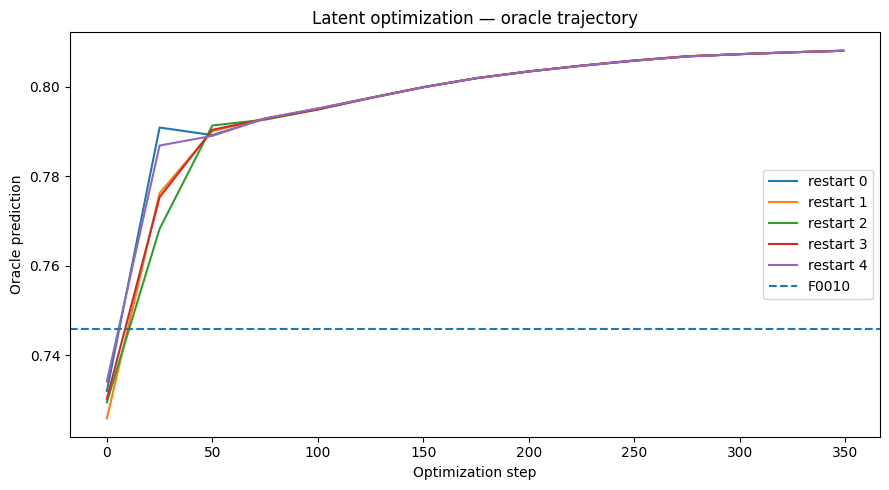

In [19]:
trace_df = pd.DataFrame(
    optimization_traces
)

if not trace_df.empty:
    plt.figure(figsize=(9, 5))

    for restart, group in (
        trace_df.groupby(
            "restart"
        )
    ):
        plt.plot(
            group["step"],
            group[
                "oracle_raw"
            ],
            label=(
                f"restart {restart}"
            ),
        )

    plt.axhline(
        seed_prediction,
        linestyle="--",
        label="F0010",
    )

    plt.xlabel("Optimization step")
    plt.ylabel(
        "Oracle prediction"
    )
    plt.title(
        "Latent optimization — oracle trajectory"
    )
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        REPORT_DIR
        / "latent_optimization_oracle_trajectories.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

## 20. Relazione miglioramento oracle ↔ distanza latente

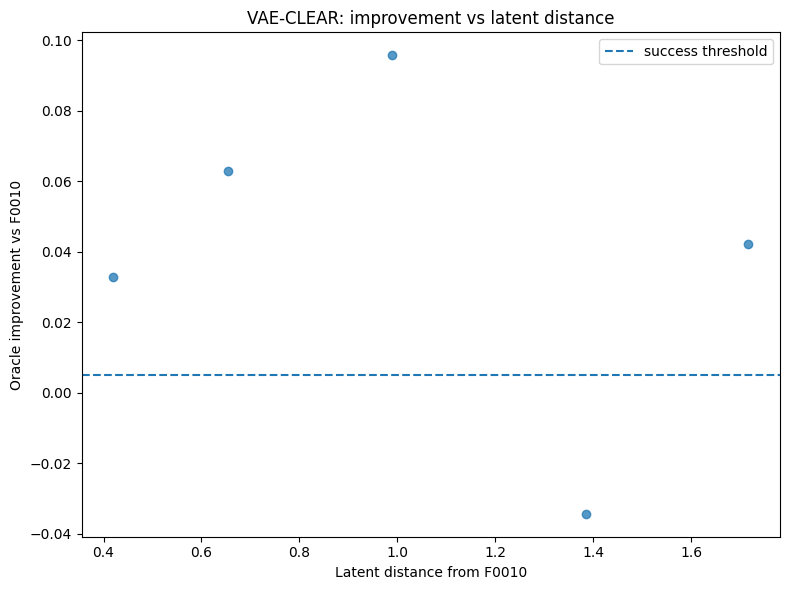

In [20]:
plot_df = candidate_df[
    candidate_df[
        "sequence"
    ] != SEED_SEQUENCE
].copy()

if not plot_df.empty:
    plt.figure(figsize=(8, 6))

    plt.scatter(
        plot_df[
            "latent_radius"
        ],
        plot_df[
            "oracle_improvement"
        ],
        alpha=0.75,
    )

    plt.axhline(
        MIN_ORACLE_IMPROVEMENT,
        linestyle="--",
        label="success threshold",
    )

    plt.xlabel(
        "Latent distance from F0010"
    )
    plt.ylabel(
        "Oracle improvement vs F0010"
    )
    plt.title(
        "VAE-CLEAR: improvement vs latent distance"
    )
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        REPORT_DIR
        / "oracle_improvement_vs_latent_distance.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

## 21. Pannello finale VAE-CLEAR

In [21]:
successful_df = (
    candidate_df[
        candidate_df[
            "successful"
        ]
    ]
    .copy()
)

# Priority:
# 1) novel candidates;
# 2) oracle improvement;
# 3) fewer mutations;
# 4) smaller latent radius.
if not successful_df.empty:
    successful_df[
        "novel_vs_04c"
    ] = (
        ~successful_df[
            "seen_in_04c"
        ]
    )

    successful_df = (
        successful_df.sort_values(
            [
                "novel_vs_04c",
                "oracle_prediction",
                "n_mutations",
                "latent_radius",
            ],
            ascending=[
                False,
                not HIGHER_IS_BETTER,
                True,
                True,
            ],
        )
        .reset_index(
            drop=True
        )
    )

    validation_panel = (
        successful_df.head(
            TOP_N_VALIDATION
        ).copy()
    )
else:
    validation_panel = (
        successful_df.copy()
    )

validation_panel[
    "vae_cf_id"
] = [
    f"VAE_CF_{i:02d}"
    for i in range(
        1,
        len(
            validation_panel
        ) + 1,
    )
]

panel_columns = [
    "vae_cf_id",
    "sequence",
    "mutations",
    "n_mutations",
    "oracle_prediction",
    "oracle_improvement",
    "latent_radius",
    "seen_in_04c",
    "direct_clear_match",
]

if "04c_target_if_seen" in (
    validation_panel.columns
):
    panel_columns += [
        "04c_target_if_seen"
    ]

display(
    validation_panel[
        panel_columns
    ]
)

,vae_cf_id,sequence,mutations,n_mutations,oracle_prediction,oracle_improvement,latent_radius,seen_in_04c,direct_clear_match,04c_target_if_seen
0,VAE_CF_01,IGERSQYRELK,C5S;D9E,2,0.841685,0.095755,0.988967,True,CF_02,0.848590
1,VAE_CF_02,IGERCQYRELK,D9E,1,0.808900,0.062971,0.654068,True,CF_03,0.836643
2,VAE_CF_03,IGERCQYREMK,D9E;L10M,2,0.788094,0.042164,1.716511,True,NaN,0.766532
3,VAE_CF_04,IGERSQYRDLK,C5S,1,0.778680,0.032750,0.419940,True,NaN,0.779836


## 22. Esportazione delle sequenze per eventuale validazione successiva

Il 06c **non esegue FoldX o Rosetta**.

Esporta semplicemente un pannello compatto che potrà essere usato nel 06d e, solo se necessario, in un successivo notebook strutturale.


In [22]:
for _, row in (
    validation_panel.iterrows()
):
    candidate_id = row[
        "vae_cf_id"
    ]

    sequence = row[
        "sequence"
    ]

    fasta_path = (
        VALIDATION_DIR
        / f"{candidate_id}.fasta"
    )

    fasta_path.write_text(
        f">{candidate_id}\n"
        f"{sequence}\n",
        encoding="utf-8",
    )

    metadata = {
        "candidate_id": (
            candidate_id
        ),
        "sequence": sequence,
        "mutations": row[
            "mutations"
        ],
        "n_mutations": int(
            row[
                "n_mutations"
            ]
        ),
        "oracle_prediction": float(
            row[
                "oracle_prediction"
            ]
        ),
        "oracle_improvement": float(
            row[
                "oracle_improvement"
            ]
        ),
        "latent_radius": float(
            row[
                "latent_radius"
            ]
        ),
        "seen_in_04c": bool(
            row[
                "seen_in_04c"
            ]
        ),
        "direct_clear_match": (
            None
            if pd.isna(
                row[
                    "direct_clear_match"
                ]
            )
            else str(
                row[
                    "direct_clear_match"
                ]
            )
        ),
    }

    metadata_path = (
        VALIDATION_DIR
        / f"{candidate_id}.json"
    )

    metadata_path.write_text(
        json.dumps(
            metadata,
            indent=2,
        ),
        encoding="utf-8",
    )

print(
    "Validation-panel files:",
    len(validation_panel),
)

Validation-panel files: 4


## 23. Esportazione delle tabelle

In [23]:
RESTARTS_CSV = (
    RESULT_DIR
    / "vae_latent_optimization_restarts.csv"
)

CANDIDATES_CSV = (
    RESULT_DIR
    / "vae_clear_candidates.csv"
)

SUCCESSFUL_CSV = (
    RESULT_DIR
    / "vae_clear_successful_candidates.csv"
)

VALIDATION_PANEL_CSV = (
    RESULT_DIR
    / "vae_clear_validation_panel.csv"
)

MUTATION_FREQUENCY_CSV = (
    RESULT_DIR
    / "vae_clear_mutation_frequencies.csv"
)

TRACE_CSV = (
    RESULT_DIR
    / "vae_latent_optimization_trace.csv"
)

restart_df.to_csv(
    RESTARTS_CSV,
    index=False,
)

candidate_df.head(
    TOP_N_EXPORT
).to_csv(
    CANDIDATES_CSV,
    index=False,
)

successful_df.to_csv(
    SUCCESSFUL_CSV,
    index=False,
)

validation_panel.to_csv(
    VALIDATION_PANEL_CSV,
    index=False,
)

mutation_frequency_df.to_csv(
    MUTATION_FREQUENCY_CSV,
    index=False,
)

trace_df.to_csv(
    TRACE_CSV,
    index=False,
)

for path in [
    RESTARTS_CSV,
    CANDIDATES_CSV,
    SUCCESSFUL_CSV,
    VALIDATION_PANEL_CSV,
    MUTATION_FREQUENCY_CSV,
    TRACE_CSV,
]:
    print(
        "Salvato:",
        path.resolve(),
    )

Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_counterfactuals_06c/vae_latent_optimization_restarts.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_counterfactuals_06c/vae_clear_candidates.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_counterfactuals_06c/vae_clear_successful_candidates.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_counterfactuals_06c/vae_clear_validation_panel.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_counterfactuals_06c/vae_clear_mutation_frequencies.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_counterfactuals_06c/vae_latent_optimization_trace.csv


## 24. Report automatico

In [24]:
n_unique = len(
    candidate_df
)

n_successful = int(
    candidate_df[
        "successful"
    ].sum()
)

n_novel = int(
    (~candidate_df[
        "seen_in_04c"
    ]).sum()
)

n_novel_successful = int(
    (
        candidate_df[
            "successful"
        ]
        & ~candidate_df[
            "seen_in_04c"
        ]
    ).sum()
)

best_candidate = (
    successful_df.iloc[0]
    if not successful_df.empty
    else None
)

if best_candidate is not None:
    best_text = (
        f"- Best VAE-CLEAR: "
        f"`{best_candidate['sequence']}`\n"
        f"- Mutations: "
        f"{best_candidate['mutations']}\n"
        f"- Oracle prediction: "
        f"{best_candidate['oracle_prediction']:.6f}\n"
        f"- Improvement vs F0010: "
        f"{best_candidate['oracle_improvement']:.6f}\n"
        f"- Latent radius: "
        f"{best_candidate['latent_radius']:.6f}\n"
        f"- Seen in 04c: "
        f"{bool(best_candidate['seen_in_04c'])}\n"
        f"- Direct CLEAR match: "
        f"{best_candidate['direct_clear_match']}"
    )
else:
    best_text = (
        "- Nessun VAE-CF sopra la soglia "
        "di miglioramento."
    )

report = f'''# 06c — CLEAR VAE Latent Counterfactual Optimization

## Method
- Seed: `{SEED_SEQUENCE}`
- Latent dimension: {VAE_LATENT_DIM}
- Restarts: {N_RESTARTS}
- Optimization steps: {OPTIMIZATION_STEPS}
- Maximum mutations: {MAX_MUTATIONS}
- Maximum latent radius: {MAX_LATENT_RADIUS}
- Minimum oracle improvement: {MIN_ORACLE_IMPROVEMENT}

## Oracle
- Target: `{TARGET_COLUMN}`
- F0010 oracle prediction: {seed_prediction:.6f}

## Results
- Unique valid decoded candidates: {n_unique}
- Successful candidates: {n_successful}
- Novel vs 04c: {n_novel}
- Novel successful candidates: {n_novel_successful}

## Best candidate
{best_text}

## Interpretation
Questo notebook realizza una vera ricerca controfattuale VAE-based:

`F0010 → encoder → z_seed → optimization in z → constrained VAE decoder → 04d oracle → hard peptide sequence`

L'ottimizzazione avviene sul vettore latente, mentre decoder VAE e oracle GNN restano congelati.

I candidati ottenuti restano ipotesi computazionali. Il 06d confronterà VAE-CLEAR e Direct CLEAR prima di decidere se eventuali nuovi candidati meritano FoldX/Rosetta.
'''

REPORT_PATH = (
    REPORT_DIR
    / "06c_vae_clear_report.md"
)

REPORT_PATH.write_text(
    report,
    encoding="utf-8",
)

print(report)
print(
    "Report:",
    REPORT_PATH.resolve(),
)

# 06c — CLEAR VAE Latent Counterfactual Optimization

## Method
- Seed: `IGERCQYRDLK`
- Latent dimension: 4
- Restarts: 80
- Optimization steps: 350
- Maximum mutations: 2
- Maximum latent radius: 2.25
- Minimum oracle improvement: 0.005

## Oracle
- Target: `oracle_target_composite_preliminary`
- F0010 oracle prediction: 0.745930

## Results
- Unique valid decoded candidates: 6
- Successful candidates: 4
- Novel vs 04c: 0
- Novel successful candidates: 0

## Best candidate
- Best VAE-CLEAR: `IGERSQYRELK`
- Mutations: C5S;D9E
- Oracle prediction: 0.841685
- Improvement vs F0010: 0.095755
- Latent radius: 0.988967
- Seen in 04c: True
- Direct CLEAR match: CF_02

## Interpretation
Questo notebook realizza una vera ricerca controfattuale VAE-based:

`F0010 → encoder → z_seed → optimization in z → constrained VAE decoder → 04d oracle → hard peptide sequence`

L'ottimizzazione avviene sul vettore latente, mentre decoder VAE e oracle GNN restano congelati.

I candidati ottenuti restano ipote

## 25. Passaggio successivo — 06d

Il prossimo notebook sarà:

```text
06d_CLEAR_VAE_vs_Direct_CLEAR_Comparison.ipynb
```

Confronterà in modo esplicito:

### Direct CLEAR — 04e
Ricerca direttamente sulle distribuzioni categoriali / trasformazioni amminoacidiche.

### VAE-CLEAR — 06c
Ricerca sul codice latente continuo appreso dal VAE.

Metriche previste:

- miglioramento oracle;
- minimalità;
- Hamming distance;
- latent distance;
- novità;
- overlap tra metodi;
- mutazioni ricorrenti;
- capacità di recuperare D9E / C5S+D9E / D9E+K11R / D9E+K11Q;
- eventuali candidati nuovi prodotti soltanto dal VAE.

Solo dopo il 06d si deciderà se è utile una nuova validazione FoldX/Rosetta di candidati VAE realmente nuovi.
